📡 Connecting to Financial Servers for 2018-TODAY Data...


/tmp/ipykernel_1537/3528108871.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers + [market, macro, world], start='2018-01-01', end='2025-12-31')['Close']
[*********************100%***********************]  9 of 9 completed
/tmp/ipykernel_1537/3528108871.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([t.split('.')[0] for t in tickers], rotation=0, fontweight='bold')


KeyError: 'Volume'

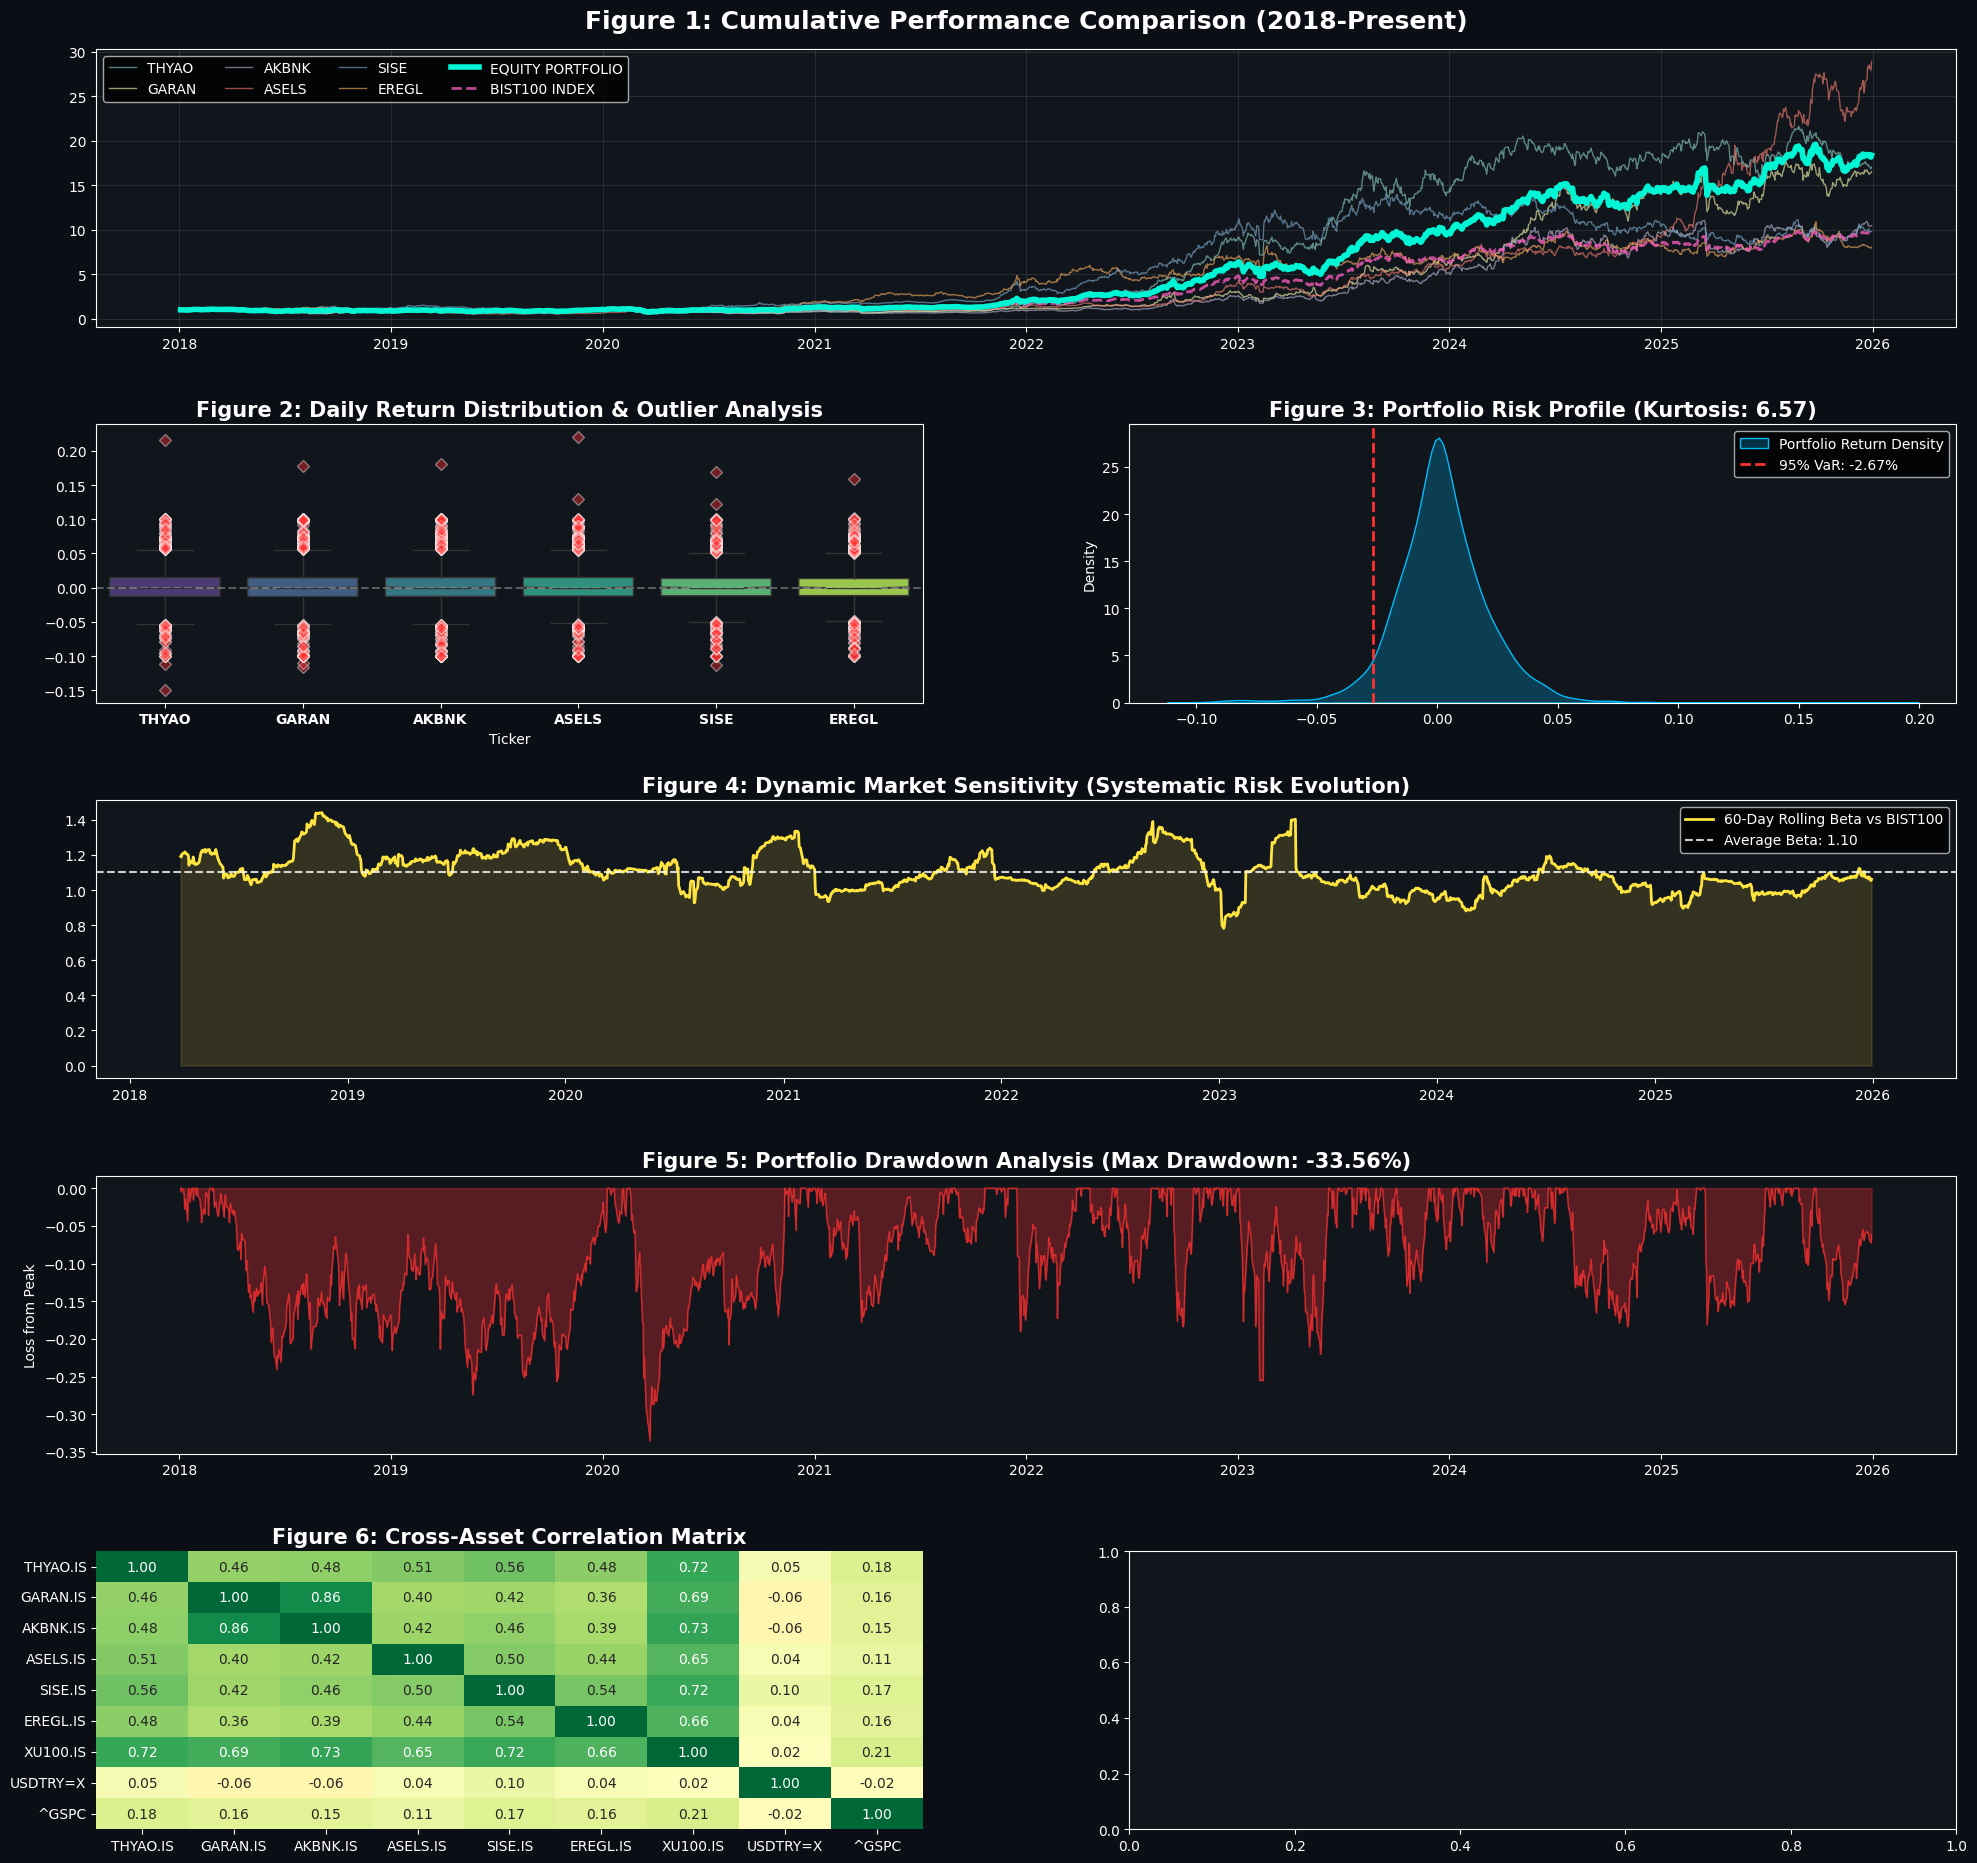

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from matplotlib.gridspec import GridSpec

# 1. DATA ACQUISITION & PREPROCESSING
tickers = ['THYAO.IS', 'GARAN.IS', 'AKBNK.IS', 'ASELS.IS', 'SISE.IS', 'EREGL.IS']
market = 'XU100.IS'
macro = 'USDTRY=X'
world = '^GSPC'

print("📡 Connecting to Financial Servers for 2018-TODAY Data...")
raw_data = yf.download(tickers + [market, macro, world], start='2018-01-01', end='2025-12-31')['Close']
data = raw_data.ffill().dropna() # Critical step to prevent empty plots by filling gaps and dropping missing rows
returns = data.pct_change().dropna()

# Categorizing returns
stock_ret = returns[tickers]
mkt_ret = returns[market]
fx_ret = returns[macro]
global_ret = returns[world]
port_ret = stock_ret.mean(axis=1) # Equal-Weighted Portfolio

# 2. ADVANCED FINANCIAL CALCULATIONS
# Value at Risk (VaR %95)
var_95 = np.percentile(port_ret, 5)

# Cumulative Returns & Max Drawdown
cum_port = (1 + port_ret).cumprod()
rolling_max = cum_port.cummax()
drawdown = (cum_port - rolling_max) / rolling_max
max_dd = drawdown.min()

# Rolling Beta (60-Day)
window = 60
rolling_beta = stock_ret.mean(axis=1).rolling(window).cov(mkt_ret) / mkt_ret.rolling(window).var()

# 3. SCIENTIFIC VISUALIZATION DASHBOARD
plt.style.use('dark_background')
fig = plt.figure(figsize=(24, 28), facecolor='#0B0E14')
gs = GridSpec(6, 2, figure=fig, hspace=0.35, wspace=0.25)

# --- FIGURE 1: CUMULATIVE PERFORMANCE (Time-Series) ---
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('#11151C')
for t in tickers:
    ax1.plot((1 + stock_ret[t]).cumprod(), label=t.split('.')[0], alpha=0.6, lw=1)
ax1.plot(cum_port, color='#00F5D4', lw=4, label='EQUITY PORTFOLIO', zorder=5)
ax1.plot((1 + mkt_ret).cumprod(), color='#F15BB5', lw=2, ls='--', label='BIST100 INDEX', alpha=0.8)
ax1.set_title("Figure 1: Cumulative Performance Comparison (2018-Present)", fontsize=18, fontweight='bold', pad=15)
ax1.legend(loc='upper left', ncol=4, frameon=True)
ax1.grid(alpha=0.1)

# --- FIGURE 2: ENHANCED BOXPLOT (Distribution & Outliers) ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('#11151C')
sns.boxplot(data=stock_ret, palette='viridis', notch=True, ax=ax2,
            flierprops={'marker': 'D', 'markerfacecolor': '#FF3131', 'markeredgecolor': 'white', 'alpha': 0.4})
ax2.set_xticklabels([t.split('.')[0] for t in tickers], rotation=0, fontweight='bold')
ax2.set_title("Figure 2: Daily Return Distribution & Outlier Analysis", fontsize=15, fontweight='bold')
ax2.axhline(0, color='white', ls='--', alpha=0.3)

# --- FIGURE 3: RETURN DENSITY & VaR (Risk Profile) ---
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('#11151C')
sns.kdeplot(port_ret, fill=True, color='#00BBF9', ax=ax3, label='Portfolio Return Density')
ax3.axvline(var_95, color='#FF3131', ls='--', lw=2, label=f'95% VaR: {var_95:.2%}')
ax3.set_title(f"Figure 3: Portfolio Risk Profile (Kurtosis: {port_ret.kurt():.2f})", fontsize=15, fontweight='bold')
ax3.legend()

# --- FIGURE 4: DYNAMIC SENSITIVITY (Rolling Beta) ---
ax4 = fig.add_subplot(gs[2, :])
ax4.set_facecolor('#11151C')
ax4.fill_between(rolling_beta.index, rolling_beta, color='#FEE440', alpha=0.15)
ax4.plot(rolling_beta, color='#FEE440', lw=2, label='60-Day Rolling Beta vs BIST100')
ax4.axhline(rolling_beta.mean(), color='white', ls='--', alpha=0.8, label=f'Average Beta: {rolling_beta.mean():.2f}')
ax4.set_title("Figure 4: Dynamic Market Sensitivity (Systematic Risk Evolution)", fontsize=15, fontweight='bold')
ax4.legend()

# --- FIGURE 5: DRAWDOWN ANALYSIS (Peak-to-Trough) ---
ax5 = fig.add_subplot(gs[3, :])
ax5.set_facecolor('#11151C')
ax5.fill_between(drawdown.index, drawdown, 0, color='#FF3131', alpha=0.3)
ax5.plot(drawdown, color='#FF3131', lw=1, alpha=0.7)
ax5.set_title(f"Figure 5: Portfolio Drawdown Analysis (Max Drawdown: {max_dd:.2%})", fontsize=15, fontweight='bold')
ax5.set_ylabel("Loss from Peak")

# --- FIGURE 6: CROSS-ASSET CORRELATION MATRIX ---
ax6 = fig.add_subplot(gs[4, 0])
full_corr = pd.concat([stock_ret, mkt_ret, fx_ret, global_ret], axis=1).corr()
sns.heatmap(full_corr, annot=True, cmap='RdYlGn', fmt='.2f', ax=ax6, cbar=False, center=0)
ax6.set_title("Figure 6: Cross-Asset Correlation Matrix", fontsize=15, fontweight='bold')

# --- FIGURE 7: VOLATILITY CLUSTERING (Trading Volume & Risk) ---
ax7 = fig.add_subplot(gs[4, 1])
ax7.set_facecolor('#11151C')
ax7.scatter(raw_data['Volume'][tickers].ffill().dropna().mean(axis=1), port_ret.abs(), alpha=0.4, color='#9b5de5', s=15)
ax7.set_title("Figure 7: Volatility Clustering & Trading Volume Relationship", fontsize=15, fontweight='bold')
ax7.set_xlabel("Average Trading Volume")
ax7.set_ylabel("Absolute Daily Return (Volatility Proxy)")

# --- FIGURE 8: MULTI-FACTOR REGRESSION (Beta Coefficients) ---
ax8 = fig.add_subplot(gs[5, :])
ax8.set_facecolor('#11151C')
X = sm.add_constant(pd.concat([mkt_ret, fx_ret, global_ret], axis=1).dropna())
reg_model = sm.OLS(port_ret.loc[X.index], X).fit()
reg_model.params[1:].plot(kind='barh', ax=ax8, color=['#00F5D4', '#F15BB5', '#9b5de5'], alpha=0.8)
ax8.set_title(f"Figure 8: Factor Sensitivities (R-Squared: {reg_model.rsquared:.2f})", fontsize=15, fontweight='bold')
for i, v in enumerate(reg_model.params[1:]):
    ax8.text(v, i, f' Beta: {v:.4f} (p={reg_model.pvalues[i+1]:.2e})', va='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

# FINAL SCIENTIFIC OUTPUTS FOR REPORT
print(f"\n{'='*80}\nACADEMIC SUMMARY STATISTICS\n{'='*80}")
print(f"1. Systematic Risk (Mean Beta): {rolling_beta.mean():.4f}")
print(f"2. Risk at Peril (95% VaR): {var_95:.4%}")
print(f"3. Recovery Metric (Max Drawdown): {max_dd:.4%}")
print(f"4. Portfolio Kurtosis (Tail Risk): {port_ret.kurt():.4f}")
print(f"5. Regression p-values:\n{reg_model.pvalues}")
print(f"{'='*80}")